In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('housing.csv')
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 2063

In [3]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


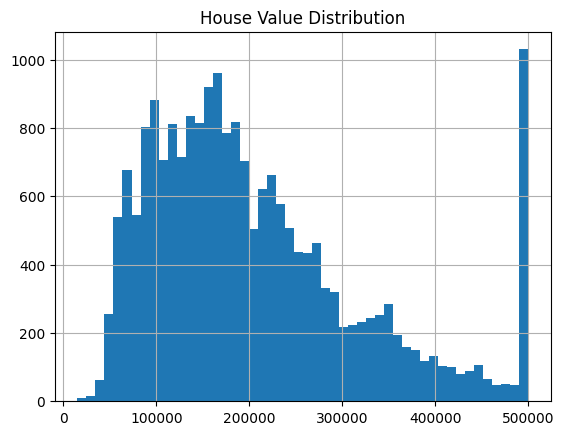

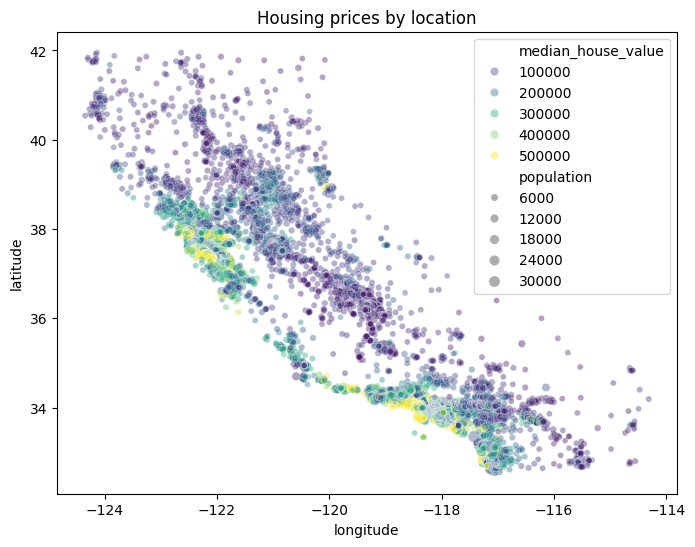

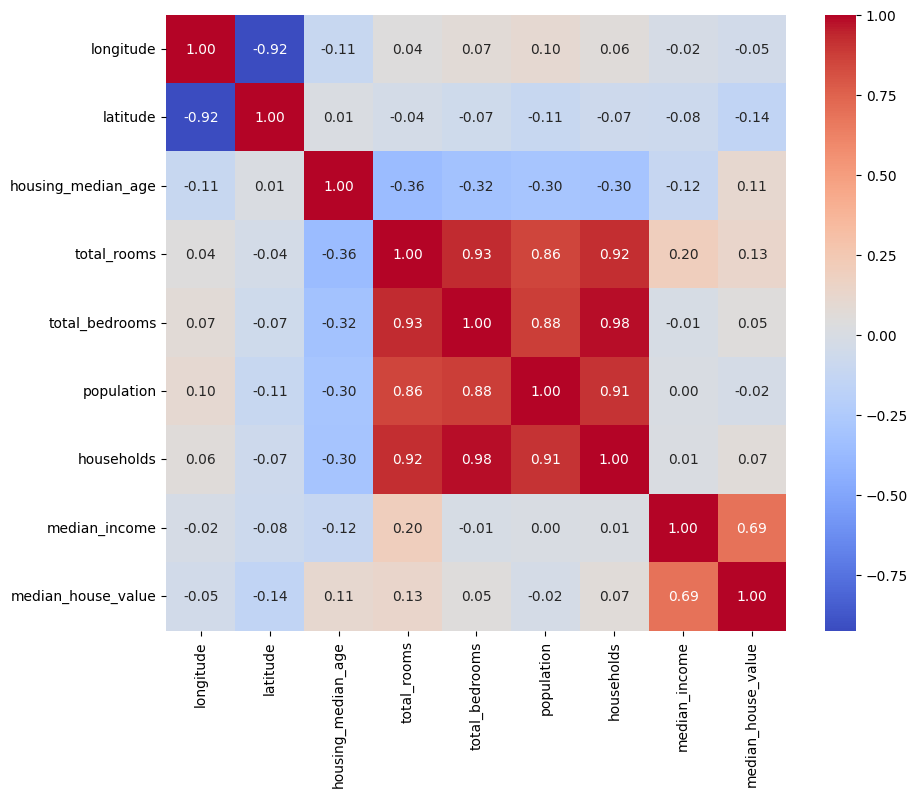

In [4]:
# Distribution of target
df['median_house_value'].hist(bins=50)
plt.title("House Value Distribution")
plt.show()

# Geographic scatter — this dataset is famous for this plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='longitude', y='latitude',
                 hue='median_house_value', size='population',
                 palette='viridis', alpha=0.4)
plt.title("Housing prices by location")
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [5]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [6]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [7]:
print(df['ocean_proximity'].value_counts())
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [8]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [9]:
corr = df.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)
print(corr)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population_per_household     -0.023737
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
bedrooms_per_room            -0.233303
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64


In [10]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only, never fit again on test data

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    # Linear model uses scaled data, tree models can use raw
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{name}: RMSE={rmse:,.0f}  MAE={mae:,.0f}  R2={r2:.4f}")

Linear Regression: RMSE=72,669  MAE=50,889  R2=0.5970
Decision Tree: RMSE=72,835  MAE=44,399  R2=0.5952
Random Forest: RMSE=50,268  MAE=32,251  R2=0.8072
Gradient Boosting: RMSE=53,666  MAE=36,601  R2=0.7802


In [12]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train,
                             scoring='neg_root_mean_squared_error', cv=5)
print("CV RMSE scores:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())

CV RMSE scores: [49722.46135287 51483.17292403 50512.80122624 49500.34181199
 50144.85669121]
Mean CV RMSE: 50272.726801266035


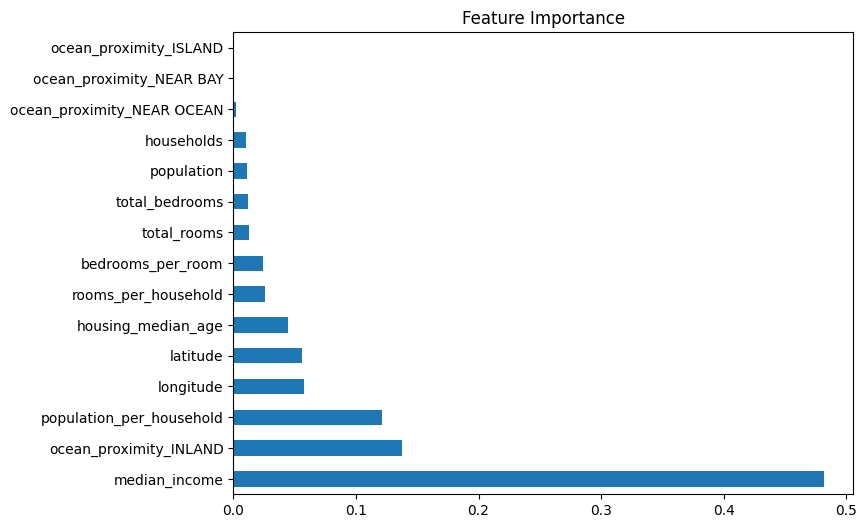

In [13]:
best_model.fit(X_train, y_train)
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

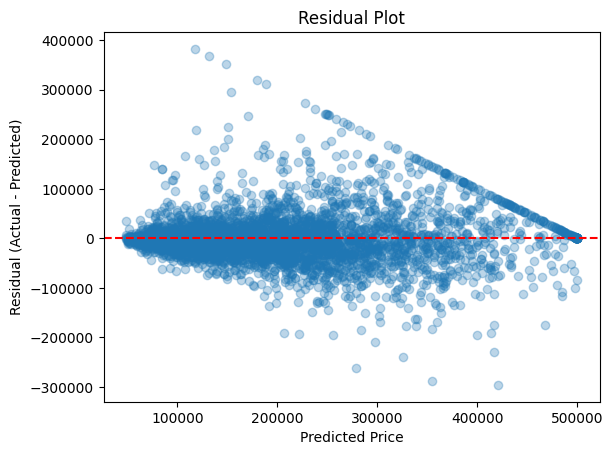

In [14]:
best_preds = best_model.predict(X_test)
residuals = y_test - best_preds

plt.scatter(best_preds, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

In [15]:
import joblib
joblib.dump(best_model, 'housing_price_model.joblib')
joblib.dump(scaler, 'housing_scaler.joblib')  # only needed if your final model is Linear Regression

['housing_scaler.joblib']